<a href="https://colab.research.google.com/github/santiruss28/data-science/blob/main/ProyectoRecomendacionCanciones_Russo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recomendación de canciones similares de Spotify
**Santiago Russó**

# 1. Introducción

## 1.1 El Dataset

### 1.1.1. Acerca del conjunto de datos

**🎧 500K + Canciones de Spotify con letras, emociones y más**

Este datset se extrajo desde Kagglehub luego de una búsqueda exhaustiva, se destaca por su cantidad de features y entradas.
Aquí el link a la página web de la fuente: [Link](https://www.kaggle.com/datasets/devdope/900k-spotify?select=spotify_dataset.csv)

En la pagina se propone que se trata dn conjunto de datos para la recomendación de música y el análisis de emociones con más de 500K pistas

### 1.1.2. Visión general


Se trata de un conjunto de datos musicales a gran escala con más de 900.000 pistas. Incluye letras, metadatos estructurados, etiquetas de emociones y más de 30 funciones contextuales y de audio por canción. Se diseñó teniendo en cuenta las aplicaciones de IA, en particular las que implican la comprensión de la música, la búsqueda semántica y la generación de listas de reproducción.

### 1.1.3. Aspectos destacados del conjunto de datos


900K+ canciones únicas con metadatos completos
Más de 30 características que incluyen:
Popularidad, Energía, Bailabilidad, Habla, Tempo, Sonoridad, Clave
Acústica, Instrumentalidad, Compás
Etiquetas contextuales (p. ej., Bueno para fiestas, Relajación, Estudio, Ejercicio, Conducir, etc.)
3 canciones similares por pista (con artista, título y puntuación de similitud)

### 1.1.4. Descripción de la Tabla

| Nombre de la columna             | Descripción                                                   | Ejemplo                                |
| -------------------------------- | ------------------------------------------------------------- | -------------------------------------- |
| `Artist(s)`                      | Nombre del artista o grupo musical que interpreta la canción. | !!!                                    |
| `song`                           | Título de la canción.                                         | Even When the Water's Cold             |
| `text`                           | Letra completa o contenido textual principal de la canción.   | "Friends told her she was better off…" |
| `Length`                         | Duración de la canción (mm\:ss).                              | 03:47                                  |
| `emotion`                        | Emoción principal extraída de las letras.                     | sadness                                |
| `Genre`                          | Género musical principal.                                     | hip hop                                |
| `Album`                          | Nombre del álbum.                                             | Thr!!!er                               |
| `Release Date`                   | Fecha de lanzamiento (DD/MM/AAAA).                            | 29/04/2013                             |
| `Key`                            | Tonalidad musical.                                            | D min                                  |
| `Tempo`                          | Tempo en BPM (normalizado).                                   | 0.437869823                            |
| `Loudness (db)`                  | Sonoridad en decibelios.                                      | 0.785065407                            |
| `Time signature`                 | Beats por compás.                                             | 4/4                                    |
| `Explicit`                       | Si tiene contenido explícito.                                 | No                                     |
| `Popularity`                     | Puntuación de popularidad.                                    | 40                                     |
| `Energy`                         | Nivel de energía (0–100).                                     | 83                                     |
| `Danceability`                   | Puntuación de bailabilidad (0–100).                           | 71                                     |
| `Positiveness`                   | Puntuación de valencia o positividad (0–100).                 | 87                                     |
| `Speechiness`                    | Presencia de palabras habladas (0–100).                       | 4                                      |
| `Liveness`                       | Probabilidad de performance en vivo (0–100).                  | 16                                     |
| `Acousticness`                   | Nivel de acústica (0–100).                                    | 11                                     |
| `Instrumentalness`               | Probabilidad de ser instrumental (0–100).                     | 0                                      |
| `Good for Party`                 | Adecuado para fiestas (binario).                              | 0                                      |
| `Good for Work/Study`            | Adecuado para trabajo/estudio (binario).                      | 0                                      |
| `Good for Relaxation/Meditation` | Adecuado para relajación/meditación (binario).                | 0                                      |
| `Good for Exercise`              | Apto para entrenamiento (binario).                            | 0                                      |
| `Good for Running`               | Apto para correr (binario).                                   | 0                                      |
| `Good for Yoga/Stretching`       | Adecuado para yoga/estiramientos (binario).                   | 0                                      |
| `Good for Driving`               | Apto para conducción (binario).                               | 0                                      |
| `Good for Social Gatherings`     | Adecuado para eventos sociales (binario).                     | 0                                      |
| `Good for Morning Routine`       | Apto para la rutina matutina (binario).                       | 0                                      |
| `Similar Artist 1`               | Primer artista más similar.                                   | Corey Smith                            |
| `Similar Song 1`                 | Primera canción similar.                                      | Si pudiera hacerlo de nuevo            |
| `Similarity Score 1`             | Puntuación de similitud (0–1).                                | 0.986060785                            |
| `Similar Artist 2`               | Segundo artista más similar.                                  | Toby Keith                             |
| `Similar Song 2`                 | Segunda canción similar.                                      | Drinks After Work                      |
| `Similarity Score 2`             | Puntuación de similitud (0–1).                                | 0.983719477                            |
| `Similar Artist 3`               | Tercer artista más similar.                                   | Space                                  |
| `Similar Song 3`                 | Tercera canción similar.                                      | Neighbourhood                          |
| `Similarity Score 3`             | Puntuación de similitud (0–1).                                | 0.983236351                            |


## 1.2. Objetivo

Le objetivo de este análsis es poder recomendar, dada una canción, otra similar basada en los features que caracterizan cada canción con características similares.

## 1.3. Justificación

La aplicación de este tipo de modelos se puede aplicar tanto para plataformas de streaming de música, para poder aumentar el engaement de los usuasriaos e incentivar que los usuarios consuman más música.  Se puede aplicar tanto para generar listas automáticas (“si te gustó esta canción, te gustarán estas otras”) como para asistir en la curaduría musical por parte de editores o DJs. Además, es altamente combinable con filtros adicionales por contexto (por ejemplo, recomendar solo dentro de un género, o solo canciones adecuadas para hacer ejercicio).

## 1.4. Metodología

Para este análisis optaremos por una combinación entre clustering y busqueda por similitud que permita escalar la recomendación y afinarla dentro de "grupos musicales" definidos.

La idea general consiste en, primero, utilizar KMeans para agrupar las canciones en clústeres según sus características acústicas y contextuales (como tempo, energía, positividad, etc.), de modo que cada clúster represente un estilo, atmósfera o tipo de canción homogénea. Luego, una vez definida esta segmentación, se aplica KNN para encontrar las canciones más cercanas a una dada dentro de su mismo grupo, es decir, se recomienda desde un subconjunto que ya comparte una identidad musical común.

Esta metodología tiene varias ventajas. En primer lugar, mejora la eficiencia computacional, ya que en lugar de buscar canciones similares en todo el dataset, lo hace dentro de un grupo previamente filtrado por semejanza general, lo que reduce drásticamente el espacio de búsqueda. Además, permite controlar la diversidad de las recomendaciones: el uso de KMeans evita que se recomienden canciones extremadamente distintas en cuanto a estilo o energía, mientras que KNN dentro del clúster asegura que las canciones propuestas sean verdaderamente cercanas al punto de partida. Es decir, se combina la visión global del clustering con la precisión local del vecino más cercano. Esta aproximación también facilita la exploración visual y el análisis de patrones: los clústeres obtenidos pueden interpretarse como “moods” o “microgéneros” emergentes, lo que es valioso para entender las preferencias musicales a nivel de catálogo.

Sin embargo, esta técnica no está exenta de limitaciones. El uso de KMeans implica decidir previamente la cantidad de clústeres (el valor de k), lo cual puede ser arbitrario si no se hace con un análisis previo, como el codo de inercia o el silhouette score. Además, al restringir la búsqueda de vecinos al clúster, podría dejar afuera canciones muy similares que justo quedaron clasificadas en otro grupo limítrofe. En otras palabras, se gana coherencia global, pero se corre el riesgo de perder finura cuando los bordes entre clústeres son difusos.


###

# 2. Preparación

## 2.1. Importación de Liberías y Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [ ]:
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "spotify_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "devdope/900k-spotify",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

C:\Users\Santi\AppData\Local\Temp\ipykernel_15036\4278773395.py:7: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


In [ ]:
df1=df.copy() #Creo una copia

In [ ]:
df=df1.copy() #Restaurar

## 2.2. EDA - Análisis Exploratorio de Datos

### 2.2.1 Limpieza

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  object 
 1   song                            551427 non-null  object 
 2   text                            551443 non-null  object 
 3   Length                          551443 non-null  object 
 4   emotion                         551443 non-null  object 
 5   Genre                           551443 non-null  object 
 6   Album                           551391 non-null  object 
 7   Release Date                    551443 non-null  object 
 8   Key                             551443 non-null  object 
 9   Tempo                           551443 non-null  int64  
 10  Loudness (db)                   551443 non-null  object 
 11  Time signature                  551435 non-null  object 
 12  Explicit        

In [ ]:
# Convertir valores 'Yes' a 1 y 'No' a 0
df['Explicit'] = df['Explicit'].map({'Yes': 1, 'No': 0})
df['Explicit'].value_counts()


Explicit
0    389378
1    162065
Name: count, dtype: int64

In [ ]:
df.drop('Time signature', axis=1, inplace=True) # dorpeo la columna Time Signature porque no la considero relevante para el modelo
df.drop('Release Date', axis=1, inplace=True) # dorpeo la columna Release Date porque no es relevante para el modelo

In [ ]:
# Usar df1 para crear la columna de segundos y luego añadirla a df
df['Length_sec'] = df1['Length'].apply(lambda x: int(x.split(":")[0]) * 60 + int(x.split(":")[1]))  # convierto el tiempo a segundos
df.drop('Legth_sec', axis=1, inplace=True, errors='ignore')  # elimina la columna con el nombre mal escrito si existe
df.drop('Length', axis=1, inplace=True, errors='ignore')     # elimina la columna original si existe

# Mostrar los primeros 5 valores y estadísticas de la columna Length_sec
print(df['Length_sec'].head())
print(df['Length_sec'].describe())

0    227
1    243
2    351
3    224
4    360
Name: Length_sec, dtype: int64
count    551443.000000
mean        223.613837
std          87.330824
min           5.000000
25%         178.000000
50%         214.000000
75%         254.000000
max        3572.000000
Name: Length_sec, dtype: float64


In [ ]:
df['Loudness (db)'] = df['Loudness (db)'].str.replace('db', '', regex=False).astype(float) # convierto loudness de string a numérico
print(df['Loudness (db)'].head())

0   -6.85
1   -5.75
2   -6.06
3   -5.42
4   -5.57
Name: Loudness (db), dtype: float64


In [ ]:
df.describe()

,Tempo,Loudness (db),Explicit,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,...,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similarity Score 1,Similarity Score 2,Similarity Score 3,Length_sec
count,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,...,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000
mean,120.513567,-8.075336,0.293893,32.258106,62.661874,59.195460,47.738330,11.663980,19.655658,25.748436,...,0.187334,0.053842,0.021484,0.057797,0.012253,0.066215,0.984107,0.979013,0.975938,223.613837
std,29.185533,4.086634,0.455544,18.033931,22.399159,17.511007,24.159671,12.342389,16.274817,29.343731,...,0.390180,0.225707,0.144990,0.233360,0.110014,0.248658,0.013559,0.015438,0.016512,87.330824
min,31.000000,-50.060000,0.000000,0.000000,0.000000,6.000000,0.000000,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002656,0.002647,0.002647,5.000000
25%,97.000000,-9.850000,0.000000,20.000000,48.000000,47.000000,28.000000,4.000000,10.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977433,0.971582,0.967926,178.000000
50%,120.000000,-7.190000,0.000000,30.000000,65.000000,60.000000,47.000000,6.000000,13.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.985926,0.980971,0.978078,214.000000
75%,140.000000,-5.370000,1.000000,43.000000,80.000000,72.000000,66.000000,15.000000,25.000000,43.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993567,0.988592,0.986079,254.000000
max,200.000000,4.980000,1.000000,100.000000,100.000000,99.000000,100.000000,97.000000,100.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3572.000000


### 2.2.2. Visualizaciones

array([[<Axes: title={'center': 'Popularity'}>,
        <Axes: title={'center': 'Energy'}>,
        <Axes: title={'center': 'Danceability'}>],
       [<Axes: title={'center': 'Positiveness'}>,
        <Axes: title={'center': 'Speechiness'}>,
        <Axes: title={'center': 'Liveness'}>],
       [<Axes: title={'center': 'Acousticness'}>,
        <Axes: title={'center': 'Instrumentalness'}>, <Axes: >]],
      dtype=object)

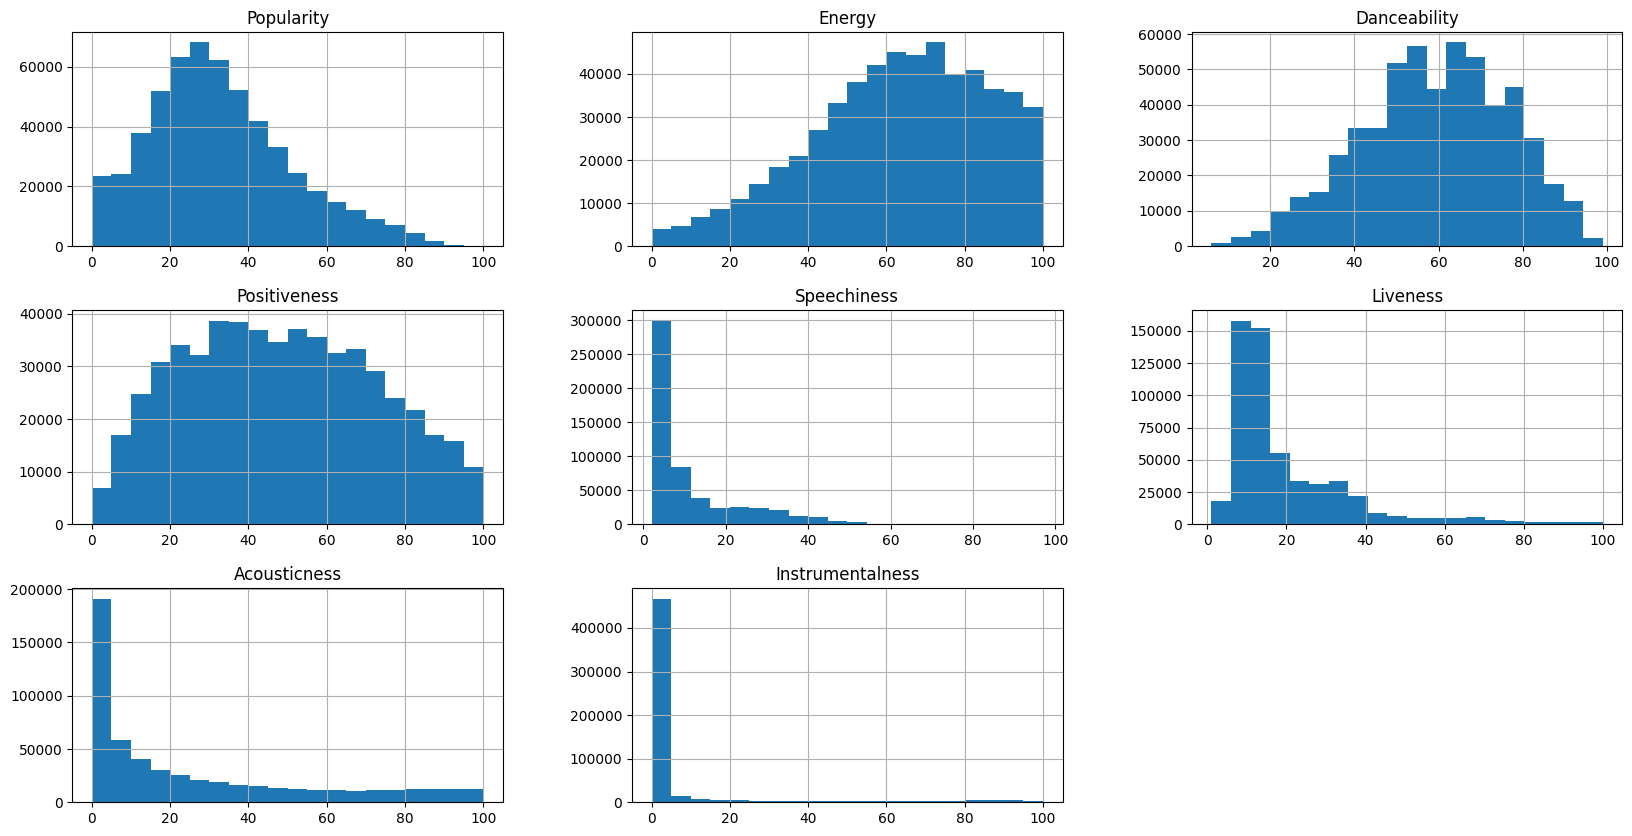

In [ ]:
# Histograma de popularidad, energía, danceability
df[['Popularity', 'Energy', 'Danceability','Positiveness','Speechiness','Liveness','Acousticness','Instrumentalness' ]].hist(bins=20, figsize=(20, 10))

<Axes: xlabel='Tempo', ylabel='Density'>

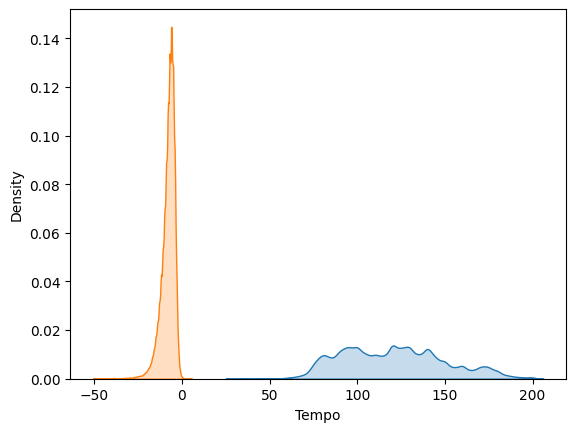

In [ ]:
# Distribución detallada
sns.kdeplot(df['Tempo'], label='Tempo', fill=True)
sns.kdeplot(df['Loudness (db)'], label='Loudness', fill=True)

<Axes: title={'center': 'Cantidad de canciones por uso'}>

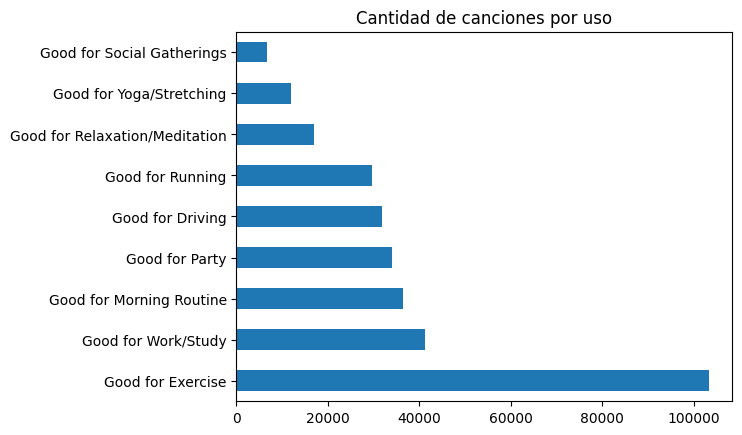

In [ ]:
binary_cols = [col for col in df.columns if col.startswith("Good for") or col.startswith("Good for ")]

df[binary_cols].sum().sort_values(ascending=False).plot(kind="barh", title="Cantidad de canciones por uso")


<Axes: >

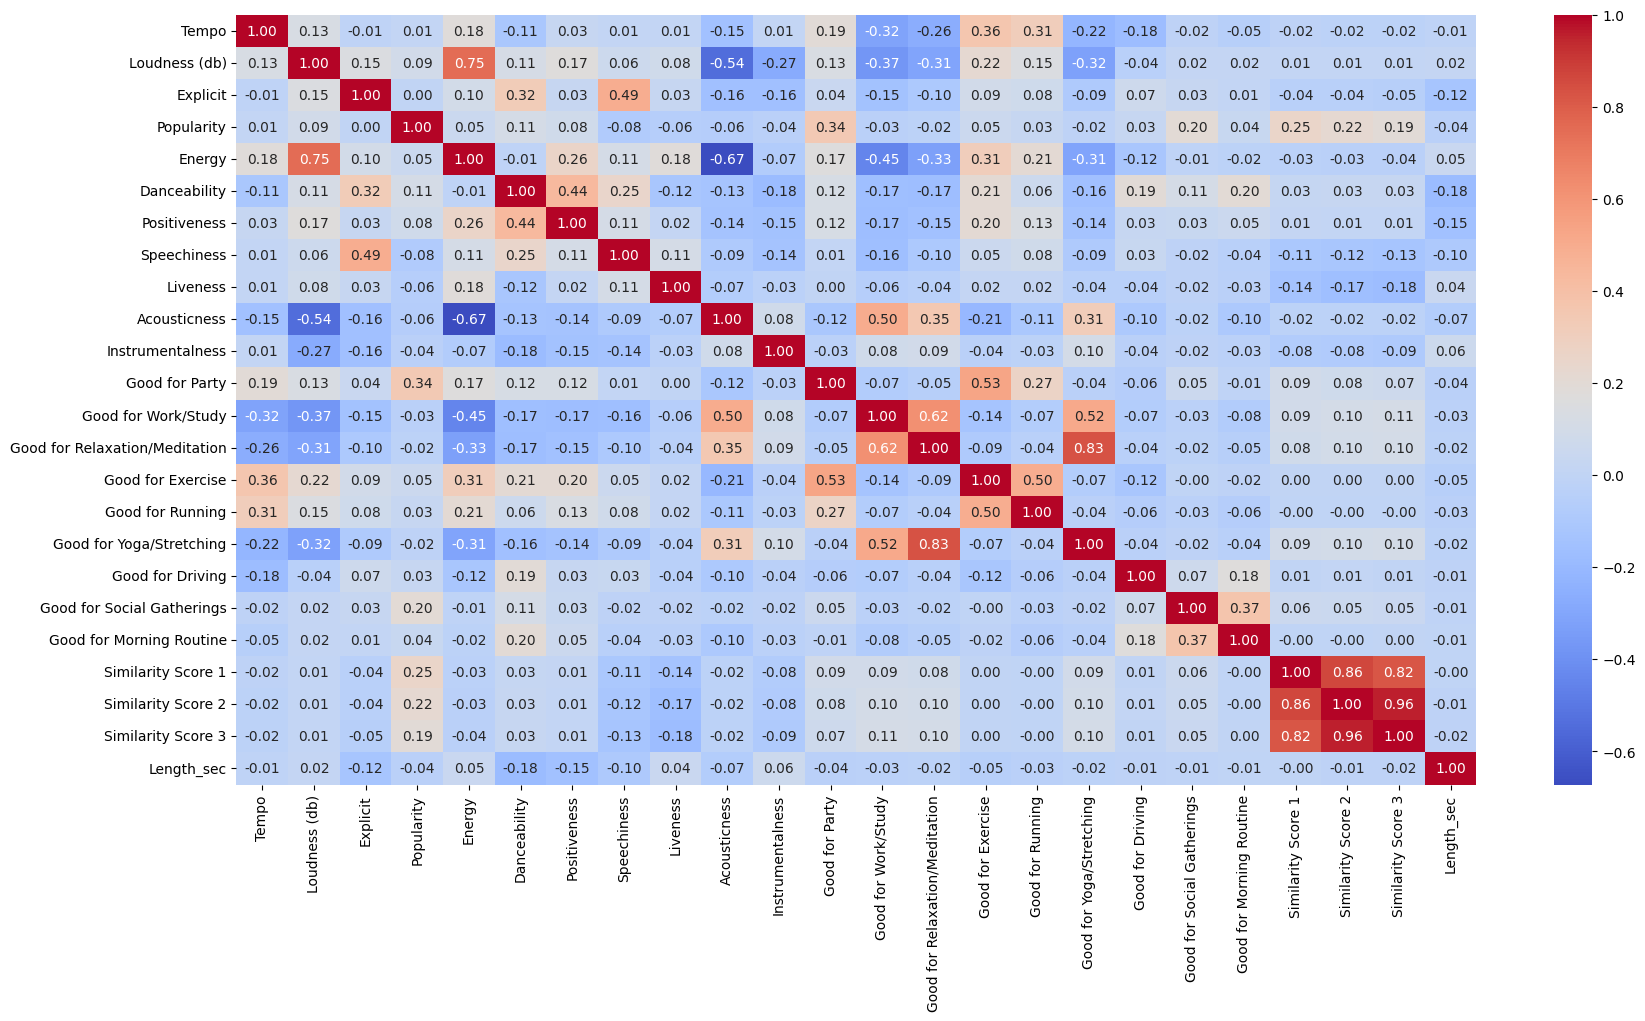

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

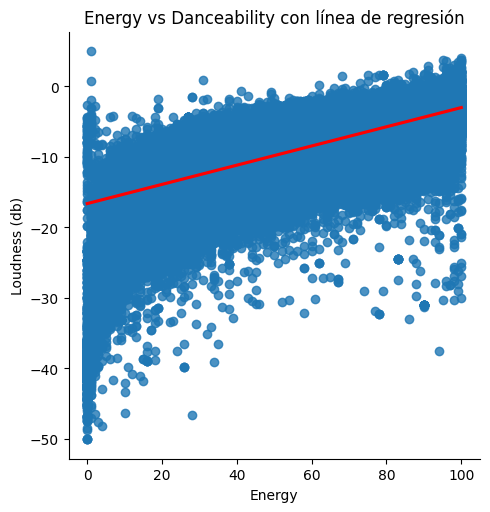

In [ ]:
sns.lmplot(x='Energy', y='Loudness (db)', data=df, line_kws={"color": "red"}) # Correlación entre energía y loudness
plt.title("Energy vs Danceability con línea de regresión")

plt.show()

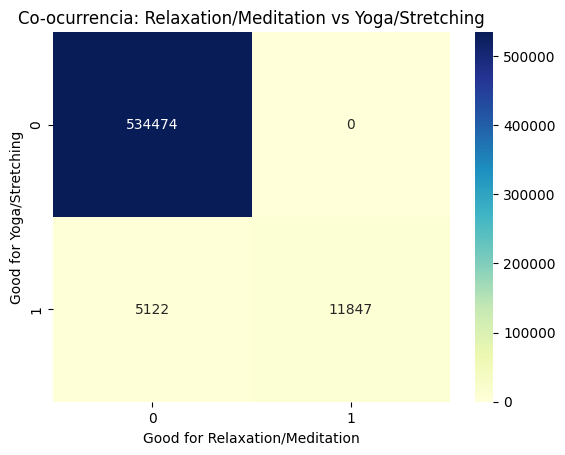

In [ ]:
tabla = pd.crosstab(df['Good for Relaxation/Meditation'], df['Good for Yoga/Stretching']) ## Correlación entre Relaxation/Meditation y Yoga/Stretching
sns.heatmap(tabla, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Co-ocurrencia: Relaxation/Meditation vs Yoga/Stretching")
plt.xlabel("Good for Relaxation/Meditation")
plt.ylabel("Good for Yoga/Stretching")
plt.show()


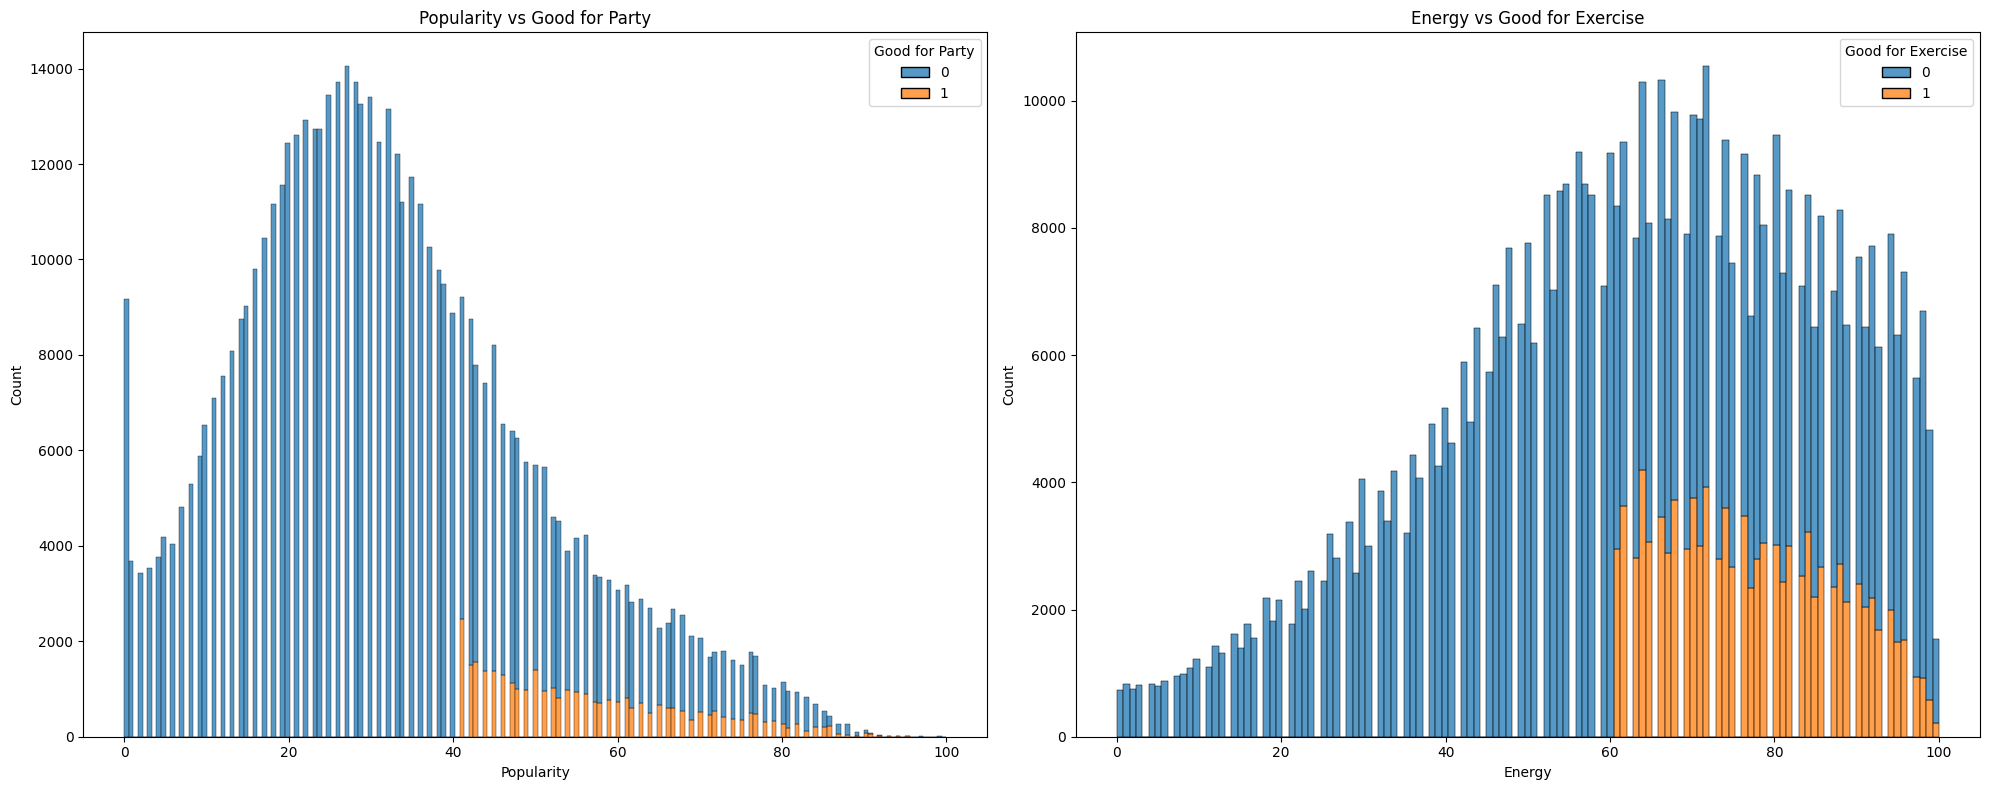

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(20, 8)) ## Relación entre Danceability y Good for Party, y entre Energy y Good for Exercise
axs[1].set_title("Energy vs Good for Exercise")
axs[0].set_title("Popularity vs Good for Party")
sns.histplot(data=df, x="Popularity", hue="Good for Party", multiple="stack", ax=axs[0])
sns.histplot(data=df, x="Energy", hue="Good for Exercise", multiple="stack",ax=axs[1])
plt.tight_layout()
plt.show()

## 2.3. Trabajo sobre nulos

In [ ]:
(df.isna().sum()/df.shape[0])*100

Artist(s)                         0.000000
song                              0.002901
text                              0.000000
emotion                           0.000000
Genre                             0.000000
Album                             0.009430
Key                               0.000000
Tempo                             0.000000
Loudness (db)                     0.000000
Explicit                          0.000000
Popularity                        0.000000
Energy                            0.000000
Danceability                      0.000000
Positiveness                      0.000000
Speechiness                       0.000000
Liveness                          0.000000
Acousticness                      0.000000
Instrumentalness                  0.000000
Good for Party                    0.000000
Good for Work/Study               0.000000
Good for Relaxation/Meditation    0.000000
Good for Exercise                 0.000000
Good for Running                  0.000000
Good for Yo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  object 
 1   song                            551427 non-null  object 
 2   text                            551443 non-null  object 
 3   emotion                         551443 non-null  object 
 4   Genre                           551443 non-null  object 
 5   Album                           551391 non-null  object 
 6   Key                             551443 non-null  object 
 7   Tempo                           551443 non-null  int64  
 8   Loudness (db)                   551443 non-null  float64
 9   Explicit                        551443 non-null  int64  
 10  Popularity                      551443 non-null  int64  
 11  Energy                          551443 non-null  int64  
 12  Danceability    

In [ ]:
# Dropear columnas por índice (de la 30 a la 38, inclusive) y por nombre específico
cols_to_drop = df.columns[27:36].tolist()  # Columnas de artistas y canciones similares

# Eliminar columnas
df = df.drop(columns=cols_to_drop)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  object 
 1   song                            551427 non-null  object 
 2   text                            551443 non-null  object 
 3   emotion                         551443 non-null  object 
 4   Genre                           551443 non-null  object 
 5   Album                           551391 non-null  object 
 6   Key                             551443 non-null  object 
 7   Tempo                           551443 non-null  int64  
 8   Loudness (db)                   551443 non-null  float64
 9   Explicit                        551443 non-null  int64  
 10  Popularity                      551443 non-null  int64  
 11  Energy                          551443 non-null  int64  
 12  Danceability    

In [ ]:
print("Filas antes:", len(df))
print("Filas con nulos:", df.isnull().any(axis=1).sum())


Filas antes: 551443
Filas con nulos: 68


In [ ]:
df = df.dropna()


In [ ]:
(df.isna().sum()/df.shape[0])*100

Artist(s)                         0.0
song                              0.0
text                              0.0
emotion                           0.0
Genre                             0.0
Album                             0.0
Key                               0.0
Tempo                             0.0
Loudness (db)                     0.0
Explicit                          0.0
Popularity                        0.0
Energy                            0.0
Danceability                      0.0
Positiveness                      0.0
Speechiness                       0.0
Liveness                          0.0
Acousticness                      0.0
Instrumentalness                  0.0
Good for Party                    0.0
Good for Work/Study               0.0
Good for Relaxation/Meditation    0.0
Good for Exercise                 0.0
Good for Running                  0.0
Good for Yoga/Stretching          0.0
Good for Driving                  0.0
Good for Social Gatherings        0.0
Good for Mor

## 2.4. Detección de Outliers

<Axes: title={'center': 'Outliers en Length_sec'}, xlabel='Length_sec'>

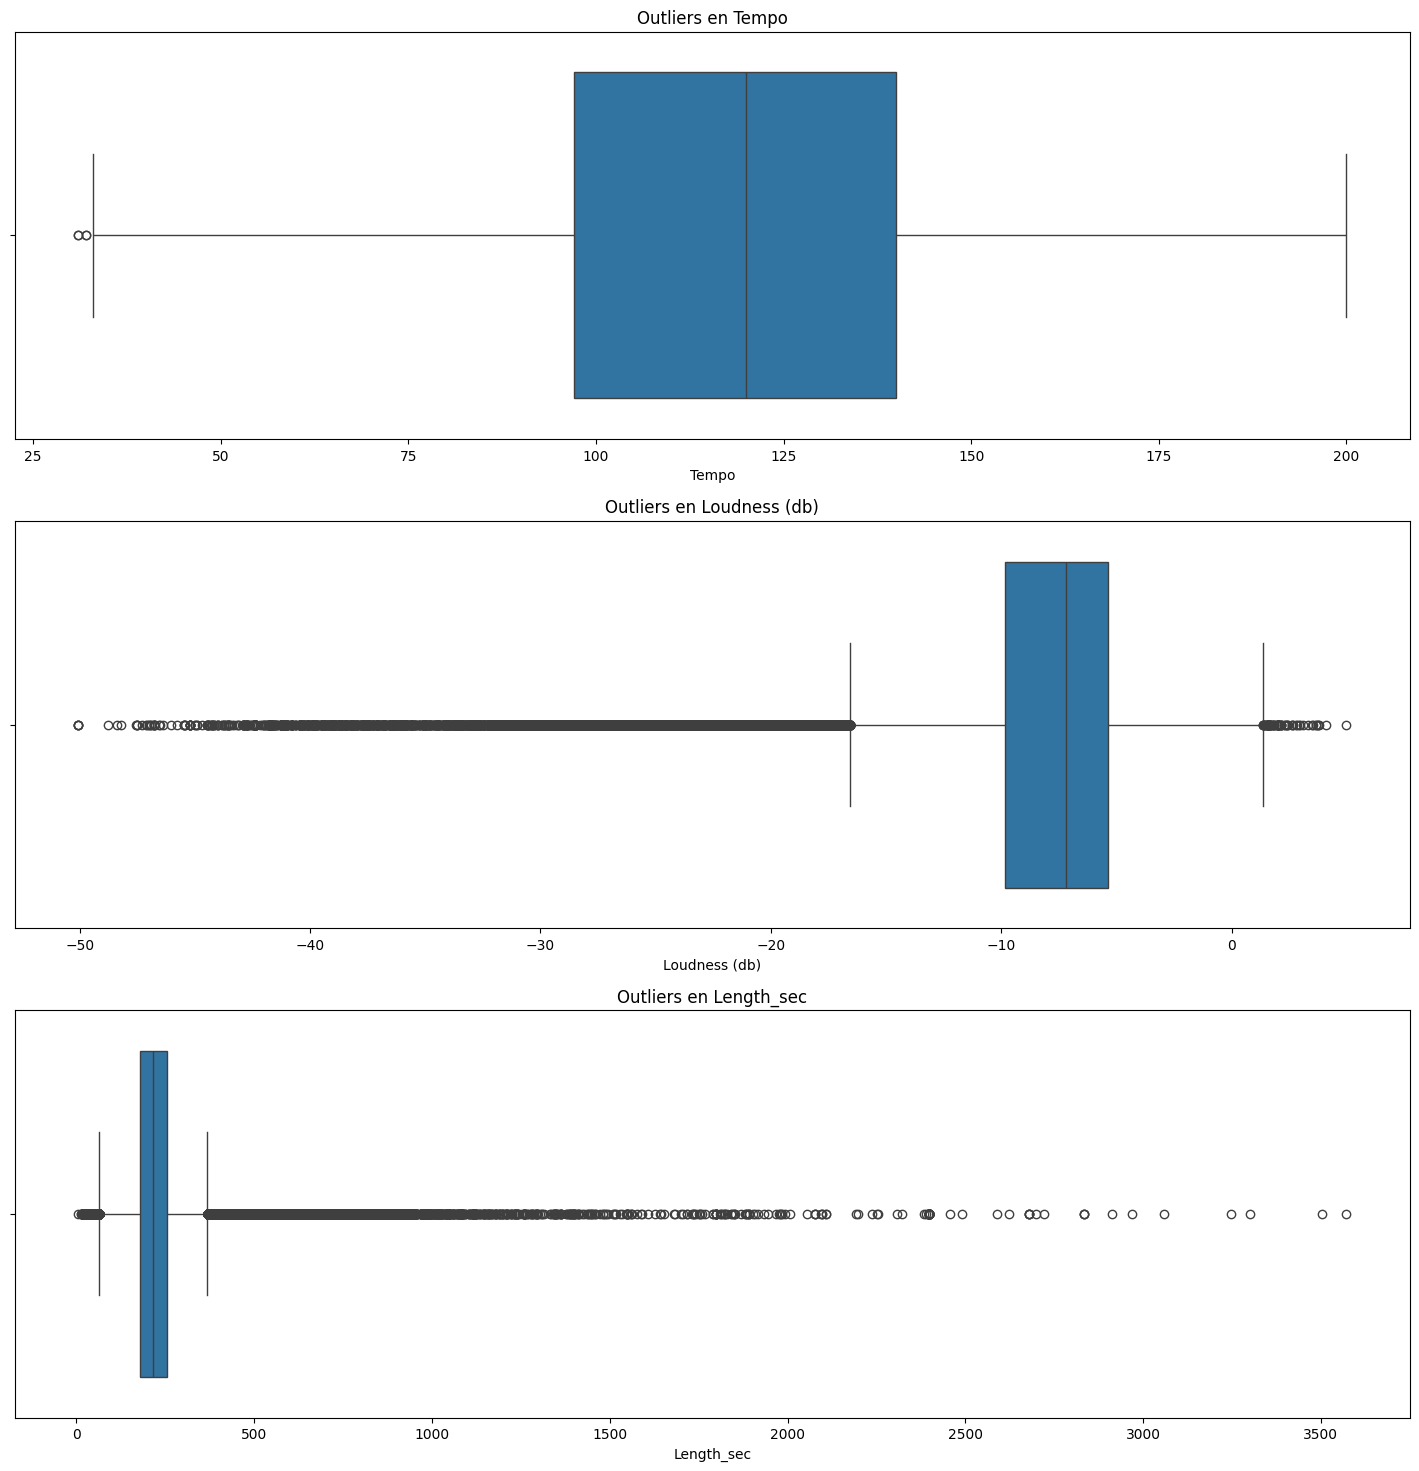

In [ ]:
fig, axs = plt.subplots(nrows=3, figsize=(18, 18))

axs[0].set_title("Outliers en Tempo")
axs[1].set_title("Outliers en Loudness (db)")
axs[2].set_title("Outliers en Length_sec")

sns.boxplot(x=df['Tempo'],ax=axs[0])
sns.boxplot(x=df['Loudness (db)'],ax=axs[1])
sns.boxplot(x=df['Length_sec'],ax=axs[2])


### Criterio
Probaremos aplicar el modelo con y sin outliers
Aplicá un filtro usando IQR o Z-score en algunas variables clave (Length_sec, Popularity, Energy, etc.).

Entrená dos modelos (con y sin outliers).

Compará los resultados: distribución de clústeres, silhouette score, visualización con PCA o t-SNE.

Esto te va a dar una idea clara de cuánto afectan los outliers realmente.

In [ ]:
Q1 = df['Length_sec'].quantile(0.25)
Q3 = df['Length_sec'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Rango aceptado: {lower} - {upper}")

# Ver cuántos valores están fuera del rango
outliers = df[(df['Length_sec'] < lower) | (df['Length_sec'] > upper)]
print(f"Outliers detectados en Length_sec: {len(outliers)}")


Q1: 178.0, Q3: 254.0, IQR: 76.0
Rango aceptado: 64.0 - 368.0
Outliers detectados en Length_sec: 25184


In [ ]:
# Definir función para eliminar outliers usando IQR
def eliminar_outliers_IQR(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    filtro = (df[columna] >= Q1 - 1.5 * IQR) & (df[columna] <= Q3 + 1.5 * IQR)
    return df[filtro]

# Aplicar a 'Length_sec'
df_no_outliers = eliminar_outliers_IQR(df, 'Length_sec')

# Aplicar a 'Loudness (db)'
df_no_outliers = eliminar_outliers_IQR(df_no_outliers, 'Loudness (db)')


In [ ]:
df_no_outliers = df_no_outliers.reset_index(drop=True)


Text(0.5, 1.0, 'Outliers en Loudness (db)')

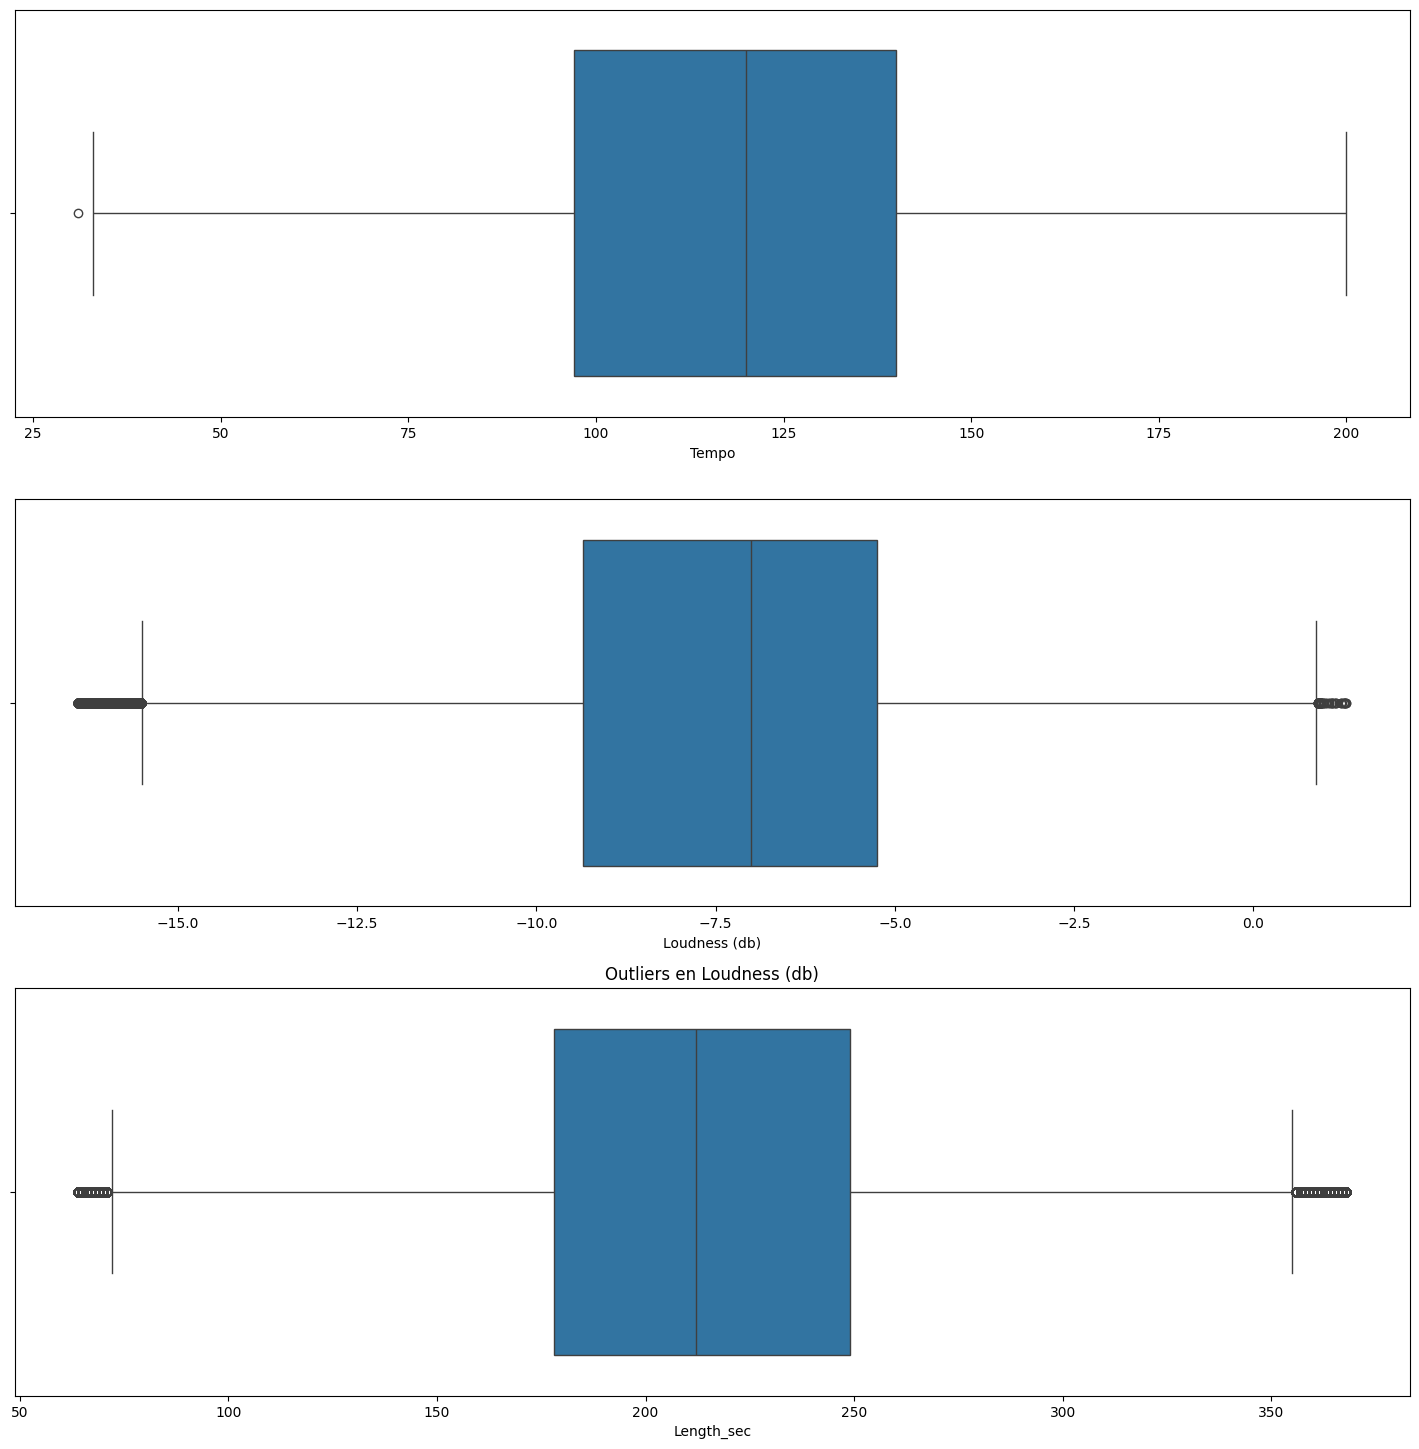

In [ ]:
fig, axs = plt.subplots(nrows=3, figsize=(18, 18))

sns.boxplot(x=df_no_outliers['Tempo'],ax=axs[0])
plt.title("Outliers en Tempo")

sns.boxplot(x=df_no_outliers['Length_sec'],ax=axs[2])
plt.title("Outliers en Legth_sec")

sns.boxplot(x=df_no_outliers['Loudness (db)'],ax=axs[1])
plt.title("Outliers en Loudness (db)")



## 2.5. Análsis de las colunas categóricas

Para el análisis de las 3 columnas categoricas que posee el dataset (Genre, Key, emotion) estableceremos un crietio para determinar si vale la pena o no aplicar One Hot Encoder. Si posee más de 20 observaciones distintas, pueden ocurrir 2 cosas
- Si es coherente, se agruparán las las categorías con pocas observaciones como "otras"  
- Si la relevancia de la columan para el modelo no es muy importante, se eliminará la columan

In [ ]:

def analizar_columna_categorica(df, columna, min_observaciones=20, max_categorias=15):
    print(f"\n📊 Análisis de la columna: '{columna}'")

    # Conteo de valores
    conteo = df[columna].value_counts()
    total_categorias = conteo.shape[0]
    print(f"🔢 Total de categorías únicas: {total_categorias}\n")

    print("📈 Observaciones por categoría (top 15):")
    print(conteo.head(15))

    # Categorías con pocas observaciones
    pocas_obs = conteo[conteo < min_observaciones]
    print(f"\n⚠️ Categorías con menos de {min_observaciones} observaciones: {len(pocas_obs)}")

    # Recomendación
    if total_categorias <= max_categorias:
        decision = "✅ Aplicar One-Hot Encoding directamente."
    elif len(pocas_obs) / total_categorias > 0.3:
        decision = f"🔧 Agrupar categorías con < {min_observaciones} observaciones como 'Other'. Luego aplicar OHE."
    else:
        decision = f"🤔 Considerar reducir categorías, revisar relevancia o posiblemente ignorar '{columna}' si no aporta mucho."

    print(f"\n📌 Recomendación: {decision}")
    return conteo


In [ ]:
conteo_generos = analizar_columna_categorica(df, 'Genre', min_observaciones=20, max_categorias=15)



📊 Análisis de la columna: 'Genre'
🔢 Total de categorías únicas: 3097

📈 Observaciones por categoría (top 15):
Genre
hip hop                             262046
pop                                  11450
country                               7391
folk                                  4897
jazz                                  3911
soul                                  3689
rock,pop,alternative rock             3526
rock                                  3460
rap,hip hop                           3396
hip hop,trap                          3297
rap,hip hop,trap                      3018
trap                                  2920
rock,heavy metal,metal                2831
rock,alternative rock,indie rock      2695
reggae                                2614
Name: count, dtype: int64

⚠️ Categorías con menos de 20 observaciones: 1622

📌 Recomendación: 🔧 Agrupar categorías con < 20 observaciones como 'Other'. Luego aplicar OHE.


In [ ]:
conteo= df['Genre'].value_counts() # Agrupamos las categorías con menos de 20 observaciones como 'Other'
#Obtengo las categorías frecuentes
frecuentes = conteo[conteo >= 20].index

#Reemplazar todo lo que no esté en "frecuentes" con 'Other'
df['Genre'] = df['Genre'].where(df['Genre'].isin(frecuentes), other='Other')

In [ ]:
conteo_generos = analizar_columna_categorica(df, 'Genre', min_observaciones=20, max_categorias=15)


📊 Análisis de la columna: 'Genre'
🔢 Total de categorías únicas: 1476

📈 Observaciones por categoría (top 15):
Genre
hip hop                             262046
pop                                  11450
Other                                 9581
country                               7391
folk                                  4897
jazz                                  3911
soul                                  3689
rock,pop,alternative rock             3526
rock                                  3460
rap,hip hop                           3396
hip hop,trap                          3297
rap,hip hop,trap                      3018
trap                                  2920
rock,heavy metal,metal                2831
rock,alternative rock,indie rock      2695
Name: count, dtype: int64

⚠️ Categorías con menos de 20 observaciones: 0

📌 Recomendación: 🤔 Considerar reducir categorías, revisar relevancia o posiblemente ignorar 'Genre' si no aporta mucho.


Decidimos dropear la columande género deberido a la enorme cantidad de categorías que posee.

In [ ]:
df = df.drop('Genre', axis=1)  # Eliminar la columna
df_no_outliers = df_no_outliers.drop('Genre', axis=1)  # Eliminar la columna

In [ ]:
conteo_generos = analizar_columna_categorica(df, 'Key', min_observaciones=20, max_categorias=15)



📊 Análisis de la columna: 'Key'
🔢 Total de categorías únicas: 24

📈 Observaciones por categoría (top 15):
Key
C Maj     47740
G Maj     47465
D Maj     44565
C# Maj    44404
A Maj     33848
G# Maj    26043
B min     25769
E min     22347
F Maj     22297
A min     21093
A# min    20259
B Maj     19763
E Maj     19632
F# min    19521
F# Maj    19466
Name: count, dtype: int64

⚠️ Categorías con menos de 20 observaciones: 0

📌 Recomendación: 🤔 Considerar reducir categorías, revisar relevancia o posiblemente ignorar 'Key' si no aporta mucho.


Resuelvo aplicar OHE debido a la significancia que puede aportar la columna Key al modelo.

In [ ]:
conteo_generos = analizar_columna_categorica(df, 'emotion', min_observaciones=20, max_categorias=15)


📊 Análisis de la columna: 'emotion'
🔢 Total de categorías únicas: 13

📈 Observaciones por categoría (top 15):
emotion
joy          208983
sadness      171052
anger        109665
fear          28096
love          27961
surprise       5592
True             17
Love              3
pink              2
thirst            1
angry             1
confusion         1
interest          1
Name: count, dtype: int64

⚠️ Categorías con menos de 20 observaciones: 7

📌 Recomendación: ✅ Aplicar One-Hot Encoding directamente.


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Columnas a codificar
categorical_cols = ['emotion', 'Key']

# Inicializar el encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')  # podés quitar drop='first' si querés todas las categorías

# Ajustar y transformar
encoded_array = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Convertir a DataFrame manteniendo el mismo índice
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

# Eliminar columnas originales y agregar las nuevas
df.drop(columns=categorical_cols, inplace=True)
df[encoded_cols] = encoded_df


In [ ]:
# Columnas a codificar
categorical_cols = ['emotion', 'Key']

# Inicializar el encoder (usando sparse_output=False para versiones nuevas de sklearn)
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Ajustar y transformar
encoded_array = encoder.fit_transform(df_no_outliers[categorical_cols])

# Nombres de las columnas codificadas
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Crear DataFrame con columnas codificadas
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df_no_outliers.index)

# Reemplazar en df_no_outliers
df_no_outliers.drop(columns=categorical_cols, inplace=True)
df_no_outliers[encoded_cols] = encoded_df


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 551375 entries, 0 to 551442
Data columns (total 60 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551375 non-null  object 
 1   song                            551375 non-null  object 
 2   text                            551375 non-null  object 
 3   Album                           551375 non-null  object 
 4   Tempo                           551375 non-null  int64  
 5   Loudness (db)                   551375 non-null  float64
 6   Explicit                        551375 non-null  int64  
 7   Popularity                      551375 non-null  int64  
 8   Energy                          551375 non-null  int64  
 9   Danceability                    551375 non-null  int64  
 10  Positiveness                    551375 non-null  int64  
 11  Speechiness                     551375 non-null  int64  
 12  Liveness             

In [ ]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507947 entries, 0 to 507946
Data columns (total 59 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       507947 non-null  object 
 1   song                            507947 non-null  object 
 2   text                            507947 non-null  object 
 3   Album                           507947 non-null  object 
 4   Tempo                           507947 non-null  int64  
 5   Loudness (db)                   507947 non-null  float64
 6   Explicit                        507947 non-null  int64  
 7   Popularity                      507947 non-null  int64  
 8   Energy                          507947 non-null  int64  
 9   Danceability                    507947 non-null  int64  
 10  Positiveness                    507947 non-null  int64  
 11  Speechiness                     507947 non-null  int64  
 12  Liveness        

## 2.6. Escalado de datos numéricos

In [ ]:
df_no_outliers = df_no_outliers.reset_index(drop=True)
df = df.reset_index(drop=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Seleccionar todas las columnas numéricas para el modelo (excluí identificadores como 'song', 'Artist(s)', etc. si siguen estando)
X = df.select_dtypes(include='number')
X_no = df_no_outliers.select_dtypes(include='number')

# Inicializar y aplicar escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_no = scaler.fit_transform(X_no)

# 3. Modelado

## 3.1. KMeans

In [ ]:
from sklearn.cluster import KMeans

Calculo de la inercia para distintos valores de k

In [ ]:
# Definir rango de k
k_range = range(1, 21)
inertias = []

# Calcular KMeans para cada k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled_no)
    inertias.append(kmeans.inertia_)

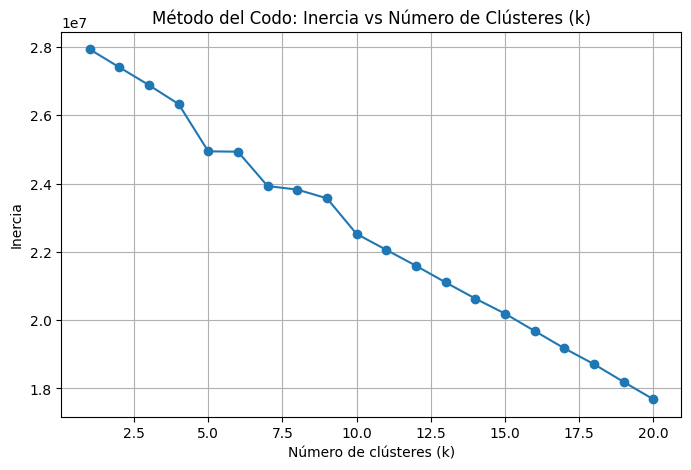

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title("Método del Codo: Inercia vs Número de Clústeres (k)")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


Vemos claramente que no hay un codo definido, sino una reducción suave y continua de la inercia, lo que indica que KMeans no encuentra clústeres bien definidos en los datos.

In [ ]:
from sklearn.utils import resample

# Muestreo aleatorio del dataset (ej: 50000 muestras) Hago esto para no exigir tanto a la GPU
X_sample = resample(X_scaled_no, n_samples=50000, random_state=42)



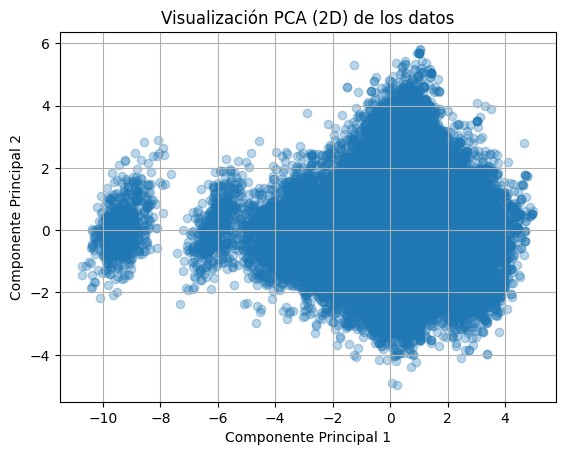

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.title("Visualización PCA (2D) de los datos")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

Vemos que existen por los menos 2 extructuras de densidad clara

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    print(f"k = {k} → Silhouette Score = {score:.4f}")


k = 2 → Silhouette Score = 0.0826
k = 3 → Silhouette Score = 0.1099
k = 4 → Silhouette Score = 0.0515
k = 5 → Silhouette Score = 0.0450
k = 6 → Silhouette Score = 0.0633
k = 7 → Silhouette Score = 0.0703
k = 8 → Silhouette Score = 0.0662
k = 9 → Silhouette Score = 0.0664
k = 10 → Silhouette Score = 0.0413


Silhouette Scores son todos menores a 0.11, eso es una señal clara de que KMeans no está encontrando clústeres bien definidos en los datos. El resultado (< 0.13) indica que los grupos no están bien separados, al menos desde el punto de vista de KMeans (que asume clústeres esféricos y de igual densidad).


| Valor   | Interpretación                            |
| ------- | ----------------------------------------- |
| > 0.5   | Clústeres bien definidos y separados      |
| 0.3–0.5 | Estructura razonable                      |
| 0.1–0.3 | Estructura débil o solapada               |
| < 0.1   | Prácticamente sin estructura de clústeres |


**¿Qué hacer ahora? Probar con DBSCAN**.
En el PCA vimos que existe al menos dos estructura de densidad clara, así que DBSCAN puede ser una buena opción

## 3.2. DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps = {eps} → {n_clusters} clústeres detectados") #Analizo la cantidad de clústeres detectados según el epsilon obtenido


eps = 0.5 → 2 clústeres detectados
eps = 0.8 → 1 clústeres detectados
eps = 1.0 → 1 clústeres detectados
eps = 1.2 → 1 clústeres detectados
eps = 1.5 → 1 clústeres detectados
eps = 2.0 → 1 clústeres detectados


In [ ]:

dbscan = DBSCAN(eps=0.5, min_samples=10) #Configuro el epsilon en base a lo que obtuve en el paso anterior
labels = dbscan.fit_predict(X_pca)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Número de clústeres encontrados: {n_clusters}")

if n_clusters > 1:
    score = silhouette_score(X_pca, labels)
    print(f"Silhouette Score (DBSCAN): {score:.3f}")
else:
    print("No se detectaron clústeres significativos.")


Número de clústeres encontrados: 2
Silhouette Score (DBSCAN): 0.582


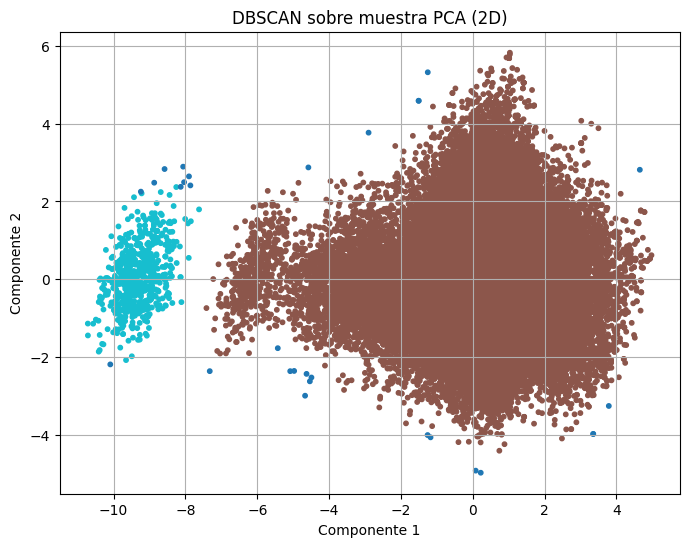

In [ ]:
# Grafico los resultados de DBSCAN sobre las componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10)
plt.title("DBSCAN sobre muestra PCA (2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

Analizando estos resultados, **no se amierita armar un modelo de recomendación basado en cluster sabiendo que sólo tengo 2**, y con un cluster que es mucho mas masivo que el otro. Es por esto que una clusterización para luego aplicar KNN no cumplirá el objetivo inicial de facilitar la busqueda de los vecinos cercanos dentro de cada cluster sabiendo que solo puedo fuormar 2. Es por esto que decido aplicar direnctamente KNN sobre el dataset completo.

## 3.3. K Nearest Neighbors

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Creamos el modelo con 6 vecinos (1 es la canción misma)
nn_model = NearestNeighbors(n_neighbors=6, metric='euclidean')
nn_model.fit(X_scaled_no)  #


NearestNeighbors(metric='euclidean', n_neighbors=6)

In [ ]:
import random  # Elijo una canción arbitraria dentro del dataset

# Elegir un índice aleatorio
random_index = random.choice(df_no_outliers.index)

# Mostrar la canción seleccionada
cancion_aleatoria = df_no_outliers.loc[random_index]
print("🎲 Canción aleatoria seleccionada:")
print(f"🎵 Título: {cancion_aleatoria['song']}")
print(f"👤 Artista: {cancion_aleatoria['Artist(s)']}")
print(f"📀 Álbum: {cancion_aleatoria['Album']}")

entrada = cancion_aleatoria['song']

🎲 Canción aleatoria seleccionada:
🎵 Título: Midnight Mouths
👤 Artista: Lauren Aquilina,filous
📀 Álbum: Midnight Mouths (filous Remix)


In [ ]:

matches = df_no_outliers[df_no_outliers['song'] == entrada]

if matches.empty:
    print(f"⚠️ No se encontró la canción '{entrada}' en el dataset.")
else:
    idx = matches.index[0]
    # ya que el índice y la posición coinciden después de reset_index()
    distancias, indices = nn_model.kneighbors([X_scaled_no[idx]])

    print(f"\n🎧 Recomendaciones similares a: '{entrada}'\n")
    for i in indices[0][1:]:
        nombre = df_no_outliers.iloc[i]['song']
        artista = df_no_outliers.iloc[i]['Artist(s)']
        print(f"🔹 {nombre} – {artista}")




🎧 Recomendaciones similares a: 'Midnight Mouths'

🔹 Lost at Sea – Kellermensch
🔹 Storms of September – Skyhill
🔹 Forgive Me – Rochus Rocky Hobi
🔹 Mouthful of Diamonds – Phantogram
🔹 Cooler Pt 2 – Gleemer


# 4. Conclusiones

En este trabajo se desarrolló un sistema de recomendación de canciones de Spotify utilizando el modelo de K-Nearest Neighbors (KNN), aplicado sobre un dataset de canciones de Spotify con diversas variables sobre la tonalidad, longiitud y emociones.

Tras la limpieza de datos que incluyó la eliminacion de valores faltantes y outliers, y codificación de variables categóricas con OHE, se aplicó escalado estandarizado para asegurar la comparabilidad entre features.

Se evaluó inicialmente la viabilidad de aplicar clustering para mejorar la busqueda de los vecinos mas cercanos dentro de cada cluster mediante KMeans y DBSCAN. Sin embargo, los resultados no presentaron una estructura de clústeres definida y agregada para segmentar el dataset con precisión en varios clusters.

Es por esto que solo se optó por utilizar directamente el modelo KNN, que permitió identificar canciones similares en función de su proximidad en el espacio de características.

El resultado final fue un recomendador de canciones que, dada una canción de entrada, devuelve otras cinco canciones similares en términos de tempo, energía, positividad, y otros atributos.